In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

In [147]:
df = pd.read_csv("/content/retail_store_inventory.csv")

In [148]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [149]:
df.tail()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring
73099,2024-01-01,S005,P0020,Groceries,East,117,6,165,2.33,78.39,20,Rainy,1,79.52,Spring


In [150]:
df.dtypes

,0
Date,object
Store ID,object
Product ID,object
Category,object
Region,object
Inventory Level,int64
Units Sold,int64
Units Ordered,int64
Demand Forecast,float64
Price,float64


In [151]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [153]:
df.nunique()

,0
Date,731
Store ID,5
Product ID,20
Category,5
Region,4
Inventory Level,451
Units Sold,498
Units Ordered,181
Demand Forecast,31608
Price,8999


In [154]:
df.shape

(73100, 15)

In [155]:
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Demand Forecast,0
Price,0


In [156]:
df.duplicated().sum()

np.int64(0)

In [157]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include="object").columns

print("Numerical Columns")
print(num_cols)

print()

print("Categorical Columns")
print(cat_cols)

Numerical Columns
Index(['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing'],
      dtype='object')

Categorical Columns
Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Weather Condition', 'Seasonality'],
      dtype='object')


In [158]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [159]:
print(df.columns)

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')


In [160]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

In [161]:
df.drop(columns=[
    "Date",
    "Store ID",
    "Product ID"
], inplace=True, errors='ignore')

In [162]:
X = df.drop("Demand Forecast", axis=1)
y = df["Demand Forecast"]

In [163]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

In [164]:
rf = RandomForestRegressor(
    n_estimators=20,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=20, random_state=42)

In [165]:
rf_pred = rf.predict(X_test)

In [166]:
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

MAE : 7.706042386869131
MSE : 82.16113673870366
RMSE: 9.064278059432183
R2 Score: 0.9931075019378598


In [168]:
!pip install xgboost

In [169]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [170]:
xgb_pred = xgb.predict(X_test)

In [171]:
print("XGBoost Results")
print("MAE :", mean_absolute_error(y_test, xgb_pred))
print("MSE :", mean_squared_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2 Score:", r2_score(y_test, xgb_pred))

XGBoost Results
MAE : 7.607039610446028
MSE : 79.13632738296366
RMSE: 8.895860126090318
R2 Score: 0.993361253205799


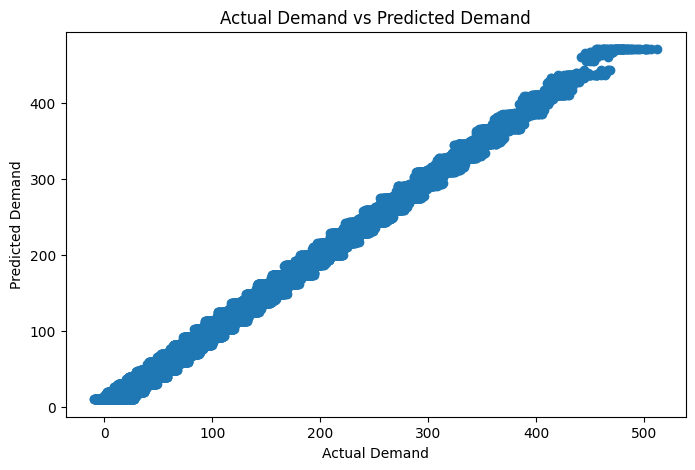

In [172]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual Demand vs Predicted Demand")

plt.show()

In [173]:
print("Random Forest R2 :", r2_score(y_test, rf_pred))
print("XGBoost R2       :", r2_score(y_test, xgb_pred))

Random Forest R2 : 0.9931075019378598
XGBoost R2       : 0.993361253205799


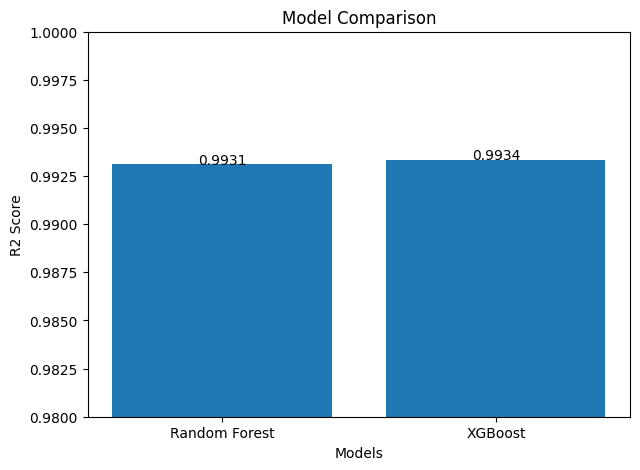

In [178]:
rf_r2 = r2_score(y_test, rf_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

models = ["Random Forest", "XGBoost"]
scores = [rf_r2, xgb_r2]

plt.figure(figsize=(7, 5))

bars = plt.bar(models, scores)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.ylim(0.98, 1.00)

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        score,
        f"{score:.4f}",
        ha="center"
    )

plt.show()

In [175]:
joblib.dump(xgb, "xgboost_model.pkl")

['xgboost_model.pkl']

In [176]:
joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [177]:
import joblib

model = joblib.load("random_forest_model.pkl")
print("Loaded Successfully")

Loaded Successfully
